# Pipeline B

## Stage 1 - Data Extraction
This stage reads image records from the final dataset without modifying files.

In [1]:
from pathlib import Path
import importlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').is_dir())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import shared.initial_image_standardization as standardization
importlib.reload(standardization)
from shared.initial_image_standardization import (
    DEFAULT_TARGET_SIZE, PADDING_VALUE, find_small_images, get_sample_images,
    inspect_image_sizes, print_dataset_summary, scan_dataset, standardize_image,
)

DATASET_ROOT = Path(os.environ.get('DATASET_ROOT', r'C:\Users\Hwang\Downloads\final_dataset'))
image_records = scan_dataset(DATASET_ROOT)
train_records = [record for record in image_records if record['split'] == 'train']
validation_records = [record for record in image_records if record['split'] == 'validation']
test_records = [record for record in image_records if record['split'] == 'test']

print(f'Train images: {len(train_records)}')
print(f'Validation images: {len(validation_records)}')
print(f'Reserved test images (untouched): {len(test_records)}')


Train images: 38937
Validation images: 5553
Reserved test images (untouched): 6519


## Stage 2 - Initial Image Standardization

This stage reads the extracted dataset without changing it. Images are resized to **512 x 512** with aspect-ratio preservation, no crop, no stretch, `cv2.INTER_AREA` when shrinking, `cv2.INTER_CUBIC` when enlarging, and neutral-gray `(114, 114, 114)` letterbox padding.

### Dataset and dimension statistics
The checks below only report unclassified images, they do not delete or modify files.

In [2]:
print_dataset_summary(image_records)
size_stats = inspect_image_sizes(train_records)
print('\nTraining-set dimension statistics')
for key in ('minimum_width', 'maximum_width', 'average_width', 'minimum_height', 'maximum_height', 'average_height', 'unreadable_image_count'):
    print(f'{key}: {size_stats[key]}')
print('Most common training resolutions (width, height):')
for resolution, count in size_stats['most_common_resolutions']:
    print(f'  {resolution}: {count}')

small_train_images = find_small_images(train_records)
print(f'\nTraining images below 64 x 64: {len(small_train_images)}')
for record in small_train_images:
    print(f"{record['path']} ({record['width']} x {record['height']})")


Total images: 51009
Single-fruit images: 47729
Multiple-fruit images: 3280
Train images: 38937
Validation images: 5553
Test images: 6519
Unclassified images: 0

Training-set dimension statistics
minimum_width: 16
maximum_width: 5184
average_width: 473.89655083853404
minimum_height: 8
maximum_height: 4608
average_height: 488.5043275034029
unreadable_image_count: 0
Most common training resolutions (width, height):
  (256, 256): 10735
  (640, 640): 5833
  (800, 800): 2903
  (224, 224): 1038
  (1020, 1020): 588
  (800, 600): 530
  (1280, 1024): 468
  (192, 256): 267
  (3456, 4608): 249
  (4608, 3456): 229

Training images below 64 x 64: 1062
C:\Users\Hwang\Downloads\final_dataset\single_fruit\train\Apple\Ripe\killa92_Apple_Ripe_0011212_crop002.jpg (59 x 89)
C:\Users\Hwang\Downloads\final_dataset\single_fruit\train\Apple\Ripe\killa92_Apple_Ripe_0019254_crop004.jpg (59 x 75)
C:\Users\Hwang\Downloads\final_dataset\single_fruit\train\Apple\Ripe\killa92_Apple_Ripe_0019254_crop007.jpg (53 x 51)


Target size: (512, 512); padding value: (114, 114, 114)


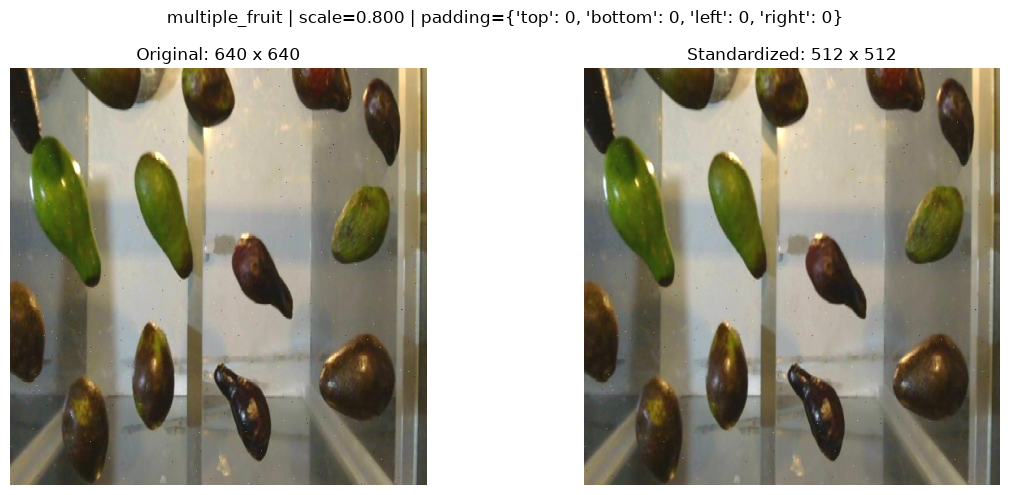

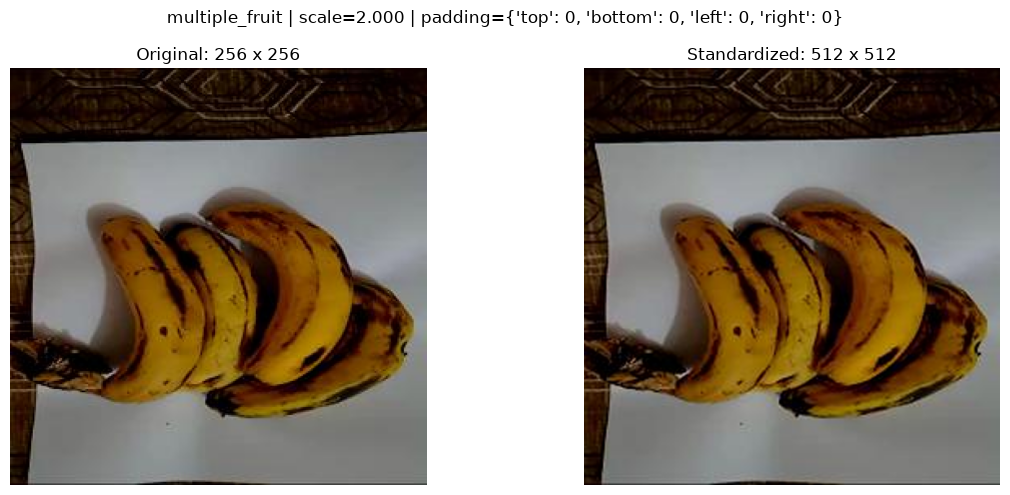

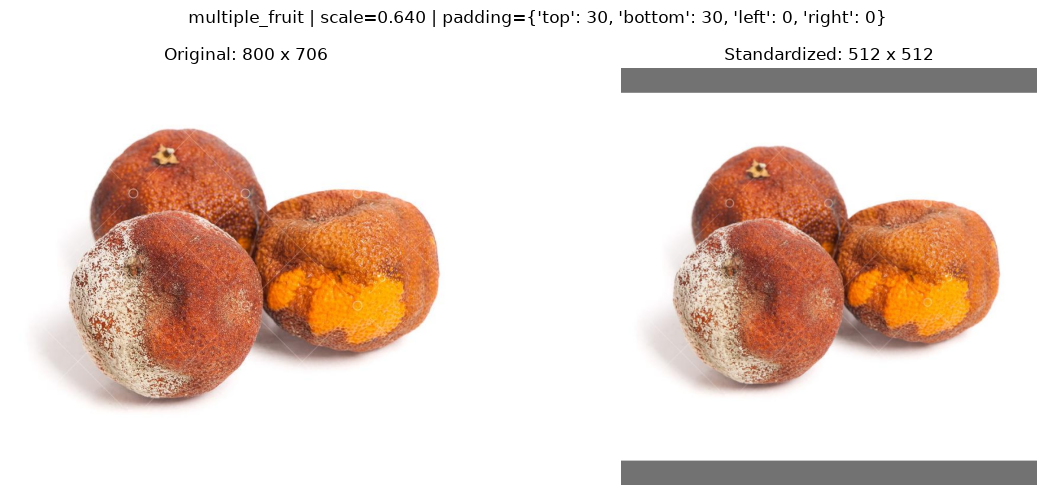

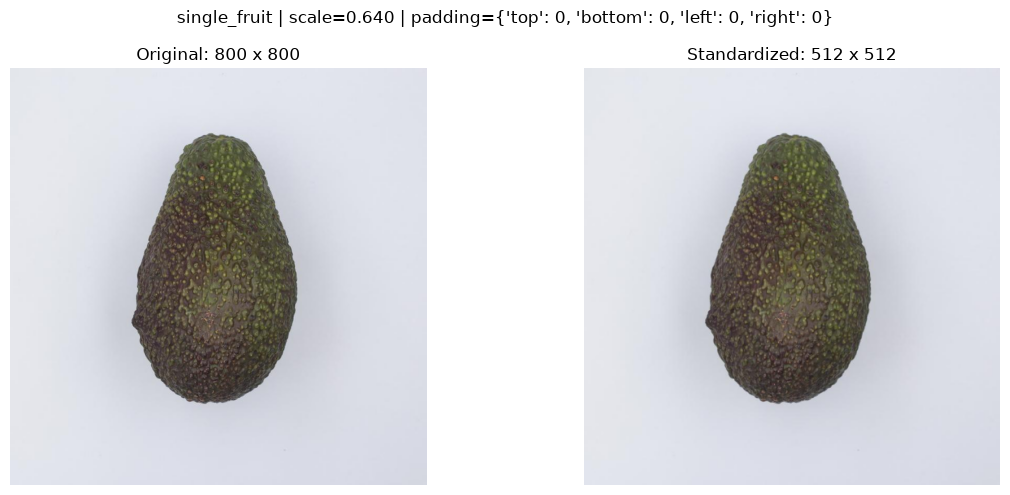

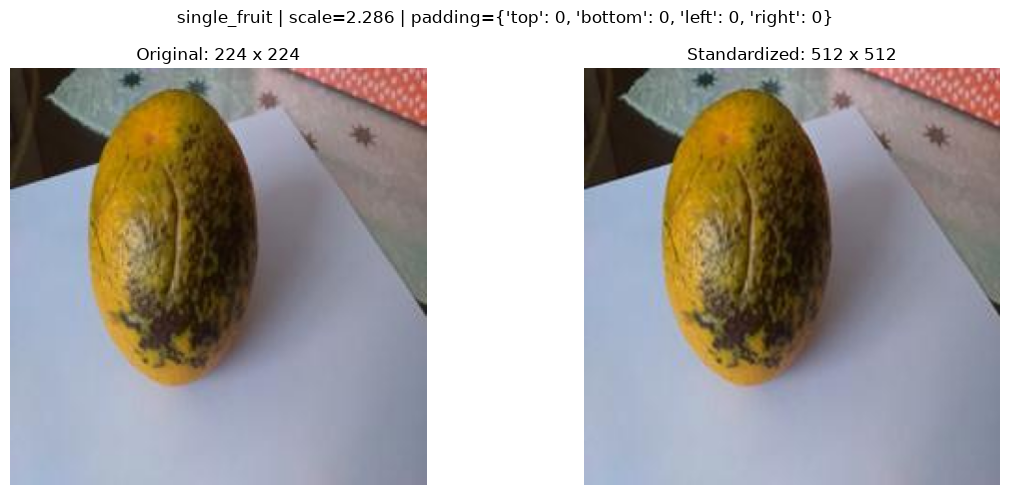

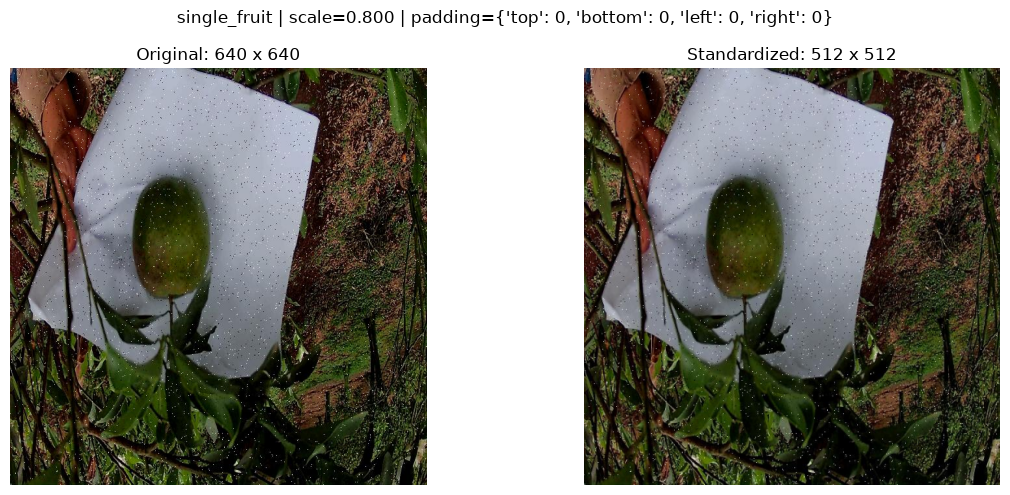

Standardized training images: 38937


In [3]:
TARGET_SIZE = DEFAULT_TARGET_SIZE  # (512, 512)
print(f'Target size: {TARGET_SIZE}; padding value: {PADDING_VALUE}')
train_sample_records = get_sample_images(train_records, single_count=3, multiple_count=3, seed=42)
train_sample_paths = {record['path'] for record in train_sample_records}
standardized_train_images = 0

for record in train_records:
    original, standardized, metadata = standardize_image(record['path'], TARGET_SIZE)
    if standardized is None:
        print(f"Skipped unreadable training image: {record['path']}")
        continue

    standardized_train_images += 1
    if record['path'] not in train_sample_paths:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original: {metadata['original_size'][0]} x {metadata['original_size'][1]}")
    axes[1].imshow(cv2.cvtColor(standardized, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Standardized: {metadata['target_size'][0]} x {metadata['target_size'][1]}")
    for axis in axes:
        axis.axis('off')
    fig.suptitle(f"{record['fruit_group']} | scale={metadata['scale_factor']:.3f} | padding={metadata['padding']}")
    plt.tight_layout()
    plt.show()

print(f'Standardized training images: {standardized_train_images}')


## Stage 3 - Preprocessing
### **Technique:** ?
### **Algorithm:** ?

?

**Supporting Article:**  
?
DOI: 

**Parameter Tuning:**
The ? are compared using the validation set. The better-performing kernel is selected and locked for Pipeline B.

**Evaluation Metrics:**

| Metric | Purpose | Better |
|---|---|---|
| BRISQUE | Perceptual image quality | ↓ Lower |
| NIQE | Natural image quality | ↓ Lower |
| PIQE | Image distortion | ↓ Lower |
| SSIM | Structural preservation | ↑ Higher |
| Processing Time | Efficiency | ↓ Lower |

The average validation results are used to select the final Median Filter kernel size.

**Evaluation Metric References:**  
Close-up hyperspectral image focus stacking through Laplacian pyramid fusion (2026)  
DOI: https://doi.org/10.1364/OE.588317  

A conditional segmentation-guided network for pomegranate image completion under occlusion (2025)  
DOI: https://doi.org/10.1186/s13007-025-01476-4

### Save Tune Results

### Training Set Processing

## Stage 4 - Segmentation